In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS_ROOT = Path("dmrs_results")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
    "figure.figsize": (6.2, 5.4),
})

velocities = np.arange(10, 101, 10)


In [5]:
def load_nmse_records(root: Path):
    records = []
    for csv_path in root.rglob("*_nmse.csv"):
        stem = csv_path.stem  # e.g., pattern1_TDD_tdd_nmse
        if stem.endswith("_tdd_nmse"):
            mode = "TDD"
            base = stem[: -len("_tdd_nmse")]
        elif stem.endswith("_fdd_nmse"):
            mode = "FDD"
            base = stem[: -len("_fdd_nmse")]
        else:
            continue
        df = pd.read_csv(csv_path, header=None)
        if df.empty:
            continue
        speeds = list(velocities[:df.shape[1]])
        nmse = df.iloc[0].tolist()
        records.append({
            "config": base,
            "mode": mode,
            "speeds": speeds,
            "nmse": nmse,
            "csv": csv_path,
        })
    return records

records = load_nmse_records(RESULTS_ROOT)
if not records:
    print(f"No *_nmse.csv found under {RESULTS_ROOT.resolve()}")
records


[{'config': 'pattern1_TDD',
  'mode': 'TDD',
  'speeds': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
  'nmse': [0.0223694160700805,
   0.02422623492537,
   0.0260123630925532,
   0.0291969235986471,
   0.0315533133163567,
   0.0369549966267039,
   0.0415626819575986,
   0.0495234012844101,
   0.0577079908501717,
   0.0713822209546642],
  'csv': PosixPath('dmrs_results/pattern1_TDD/pattern1_TDD_tdd_nmse.csv')},
 {'config': 'pattern1_FDD',
  'mode': 'FDD',
  'speeds': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
  'nmse': [0.5370535610183593,
   0.4595838689034985,
   0.4501990397130289,
   0.431541254443507,
   0.4349692175465245,
   0.4573084404391627,
   0.4144826550637522,
   0.4286463568287511,
   0.4590213452616045,
   0.4676516527129757],
  'csv': PosixPath('dmrs_results/pattern1_FDD/pattern1_FDD_fdd_nmse.csv')},
 {'config': 'pattern2_TDD',
  'mode': 'TDD',
  'speeds': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
  'nmse': [0.0242594072234726,
   0.0264271464979937,
   0.02846896516219

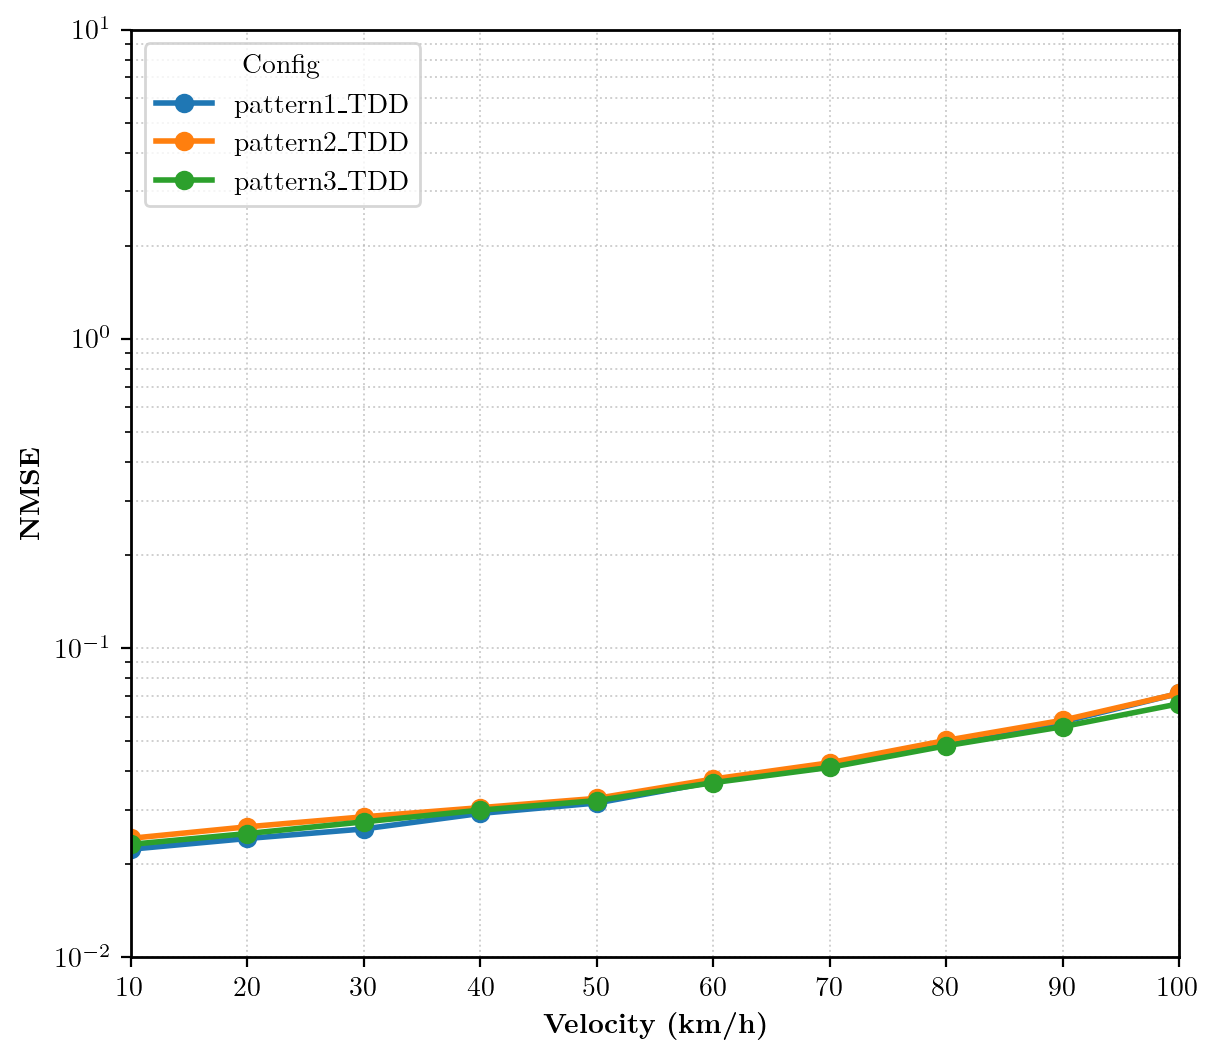

In [6]:
# Plot TDD
recs = [r for r in records if r.get("mode") == "TDD"]
if not recs:
    print("No TDD records found.")
else:
    plt.figure(figsize=(6.2, 5.4), dpi=200)
    ax = plt.gca()
    ax.set_yscale("log")
    for r in recs:
        ax.plot(velocities, r["nmse"], marker="o", linewidth=2.0, markersize=6, label=r["config"])
    ax.set_xlabel(r"\textbf{Velocity (km/h)}")
    ax.set_ylabel(r"\textbf{NMSE}")
    ax.set_xlim(10, 100)
    ax.set_ylim(1e-2, 10)
    ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
    ax.set_xticks(list(velocities))
    ax.legend(loc="upper left", frameon=True, title="Config")
    plt.tight_layout()
    plt.show()


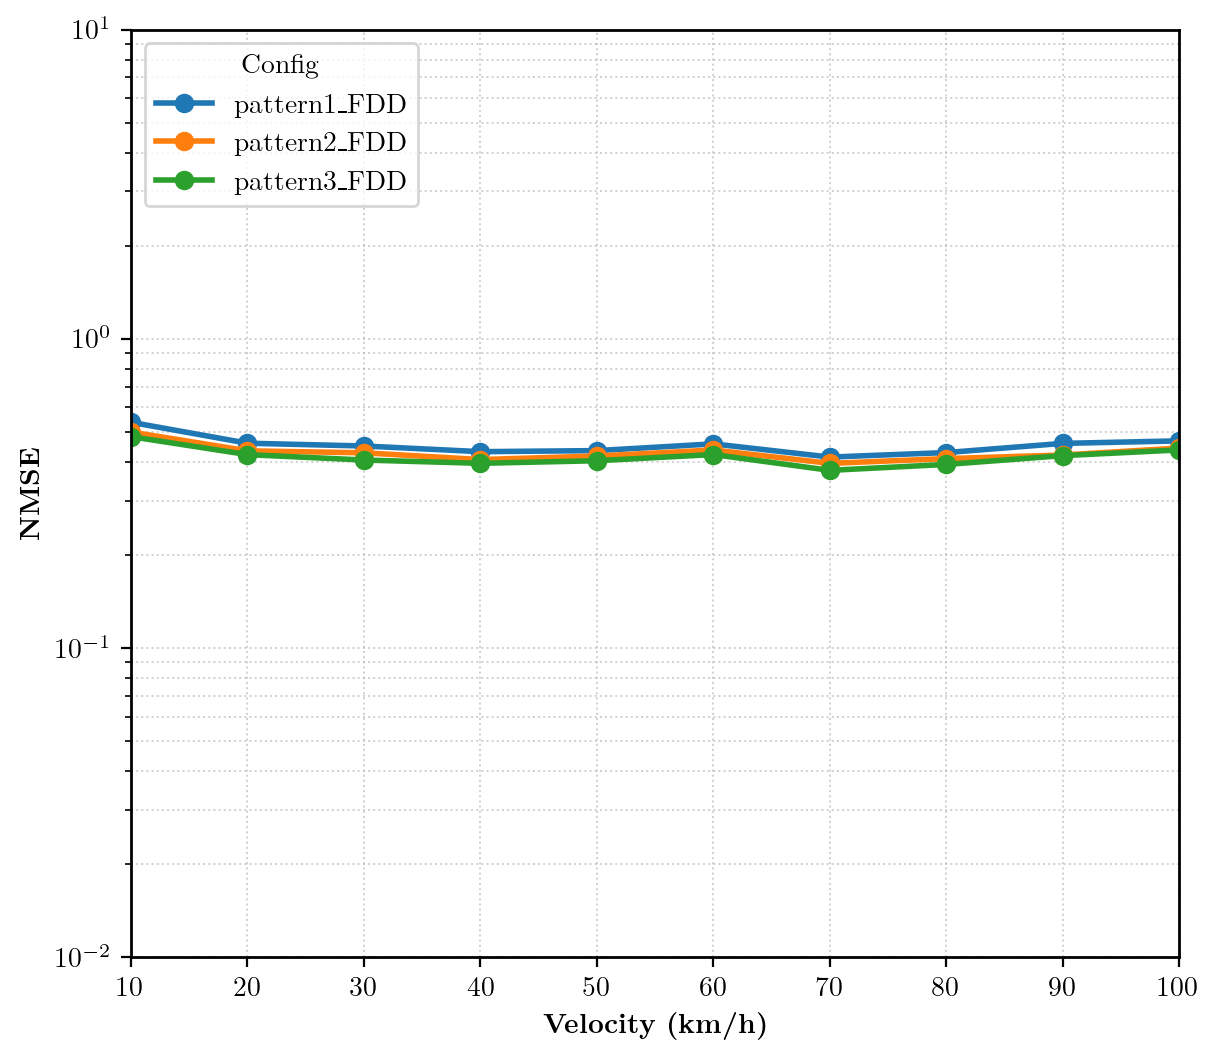

In [7]:
# Plot FDD
recs = [r for r in records if r.get("mode") == "FDD"]
if not recs:
    print("No FDD records found.")
else:
    plt.figure(figsize=(6.2, 5.4), dpi=200)
    ax = plt.gca()
    ax.set_yscale("log")
    for r in recs:
        ax.plot(velocities, r["nmse"], marker="o", linewidth=2.0, markersize=6, label=r["config"])
    ax.set_xlabel(r"\textbf{Velocity (km/h)}")
    ax.set_ylabel(r"\textbf{NMSE}")
    ax.set_xlim(10, 100)
    ax.set_ylim(1e-2, 10)
    ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
    ax.set_xticks(list(velocities))
    ax.legend(loc="upper left", frameon=True, title="Config")
    plt.tight_layout()
    plt.show()
